In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load feature-engineered dataset
data_path = Path("../data/processed/climacare_features.csv")

df = pd.read_csv(data_path)

# Convert date back to datetime
df["date"] = pd.to_datetime(df["date"])

print("ClimaCare feature dataset loaded successfully!")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

ClimaCare feature dataset loaded successfully!
Shape: (1291, 30)
Date range: 2022-08-08 00:00:00 to 2026-02-18 00:00:00


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,...,pm2_5_lag1,pm10_lag1,us_aqi_lag1,pm2_5_roll3,pm10_roll3,us_aqi_roll3,pm_ratio,dust_wind,temp_humidity,season_encoded
0,2022-08-08,103.125000,62.745833,607.625000,94.858333,18.945833,152.666667,0.353750,29.250000,2.272917,...,93.758333,150.691667,180.291667,71.318056,114.173611,158.408333,0.608444,2.683486,1365.213889,2
1,2022-08-09,76.595833,45.358333,602.625000,107.912500,24.212500,63.375000,0.339167,26.083333,2.366667,...,62.745833,103.125000,207.166667,74.251389,119.629167,179.847222,0.592178,2.275536,1636.906250,2
2,2022-08-10,114.862500,59.287500,766.916667,115.254167,26.708333,99.541667,0.485000,66.875000,2.141667,...,45.358333,76.595833,146.791667,67.287500,110.137500,178.083333,0.516161,5.325149,1954.739583,2
3,2022-08-11,165.525000,75.741667,938.333333,137.954167,36.704167,72.916667,0.634167,133.333333,1.954167,...,59.287500,114.862500,144.583333,55.797222,98.194444,166.180556,0.457584,11.379800,1966.703125,2
4,2022-08-12,190.825000,116.433333,1071.583333,117.541667,25.470833,105.625000,0.738333,53.916667,1.887500,...,75.741667,165.525000,157.083333,60.129167,118.994444,149.486111,0.610158,4.111852,1559.029687,2


In [2]:
# ---------------------------------------------------------
# Create next-day US AQI prediction target
# ---------------------------------------------------------

# Make sure data is sorted chronologically
df = df.sort_values("date").reset_index(drop=True)

# Tomorrow's AQI becomes the prediction target
df["target_aqi_next_day"] = df["us_aqi"].shift(-1)

print("Target created successfully!")

# Display current AQI and next-day target
display(
    df[["date", "us_aqi", "target_aqi_next_day"]].head(10)
)

print("\nMissing target values:", 
      df["target_aqi_next_day"].isna().sum())

Target created successfully!


,date,us_aqi,target_aqi_next_day
0,2022-08-08,207.166667,146.791667
1,2022-08-09,146.791667,144.583333
2,2022-08-10,144.583333,157.083333
3,2022-08-11,157.083333,167.625000
4,2022-08-12,167.625000,180.500000
5,2022-08-13,180.500000,158.333333
6,2022-08-14,158.333333,132.000000
7,2022-08-15,132.000000,112.166667
8,2022-08-16,112.166667,147.416667
9,2022-08-17,147.416667,147.708333



Missing target values: 1


In [3]:
# ---------------------------------------------------------
# Prepare dataset for machine learning
# ---------------------------------------------------------

# Remove the final row because it has no next-day target
df_model = df.dropna(subset=["target_aqi_next_day"]).copy()

# Columns that should NOT be directly used as model inputs
drop_columns = [
    "date",
    "target_aqi_next_day",
    "season"   # We already have season_encoded
]

# Create features (X) and target (y)
X = df_model.drop(columns=drop_columns)

y = df_model["target_aqi_next_day"]

print("Machine-learning dataset prepared successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used:")
for feature in X.columns:
    print("-", feature)

print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Machine-learning dataset prepared successfully!
X shape: (1290, 28)
y shape: (1290,)

Features used:
- pm10
- pm2_5
- carbon_monoxide
- nitrogen_dioxide
- sulphur_dioxide
- ozone
- aerosol_optical_depth
- dust
- uv_index
- us_aqi
- european_aqi
- temperature
- humidity
- wind_speed
- year
- month
- day
- day_of_week
- pm2_5_lag1
- pm10_lag1
- us_aqi_lag1
- pm2_5_roll3
- pm10_roll3
- us_aqi_roll3
- pm_ratio
- dust_wind
- temp_humidity
- season_encoded

Missing values in X: 0
Missing values in y: 0


In [4]:
# ---------------------------------------------------------
# Chronological train-test split
# ---------------------------------------------------------

split_index = int(len(df_model) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = df_model["date"].iloc[:split_index]
test_dates = df_model["date"].iloc[split_index:]

print("Chronological split completed successfully!")

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nOverlap check:")
print("Last training date:", train_dates.max())
print("First testing date:", test_dates.min())

Chronological split completed successfully!

Training samples: 1032
Testing samples: 258

Training period:
2022-08-08 00:00:00 to 2025-06-04 00:00:00

Testing period:
2025-06-05 00:00:00 to 2026-02-17 00:00:00

X_train shape: (1032, 28)
X_test shape: (258, 28)
y_train shape: (1032,)
y_test shape: (258,)

Overlap check:
Last training date: 2025-06-04 00:00:00
First testing date: 2025-06-05 00:00:00


In [5]:
# ---------------------------------------------------------
# Baseline model: Today's AQI predicts tomorrow's AQI
# ---------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline prediction
baseline_pred = X_test["us_aqi"].values

# Evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("BASELINE MODEL RESULTS")
print("-" * 40)
print(f"MAE  : {baseline_mae:.3f}")
print(f"RMSE : {baseline_rmse:.3f}")
print(f"R²   : {baseline_r2:.3f}")

BASELINE MODEL RESULTS
----------------------------------------
MAE  : 12.400
RMSE : 16.651
R²   : 0.579


In [6]:
# ---------------------------------------------------------
# Model 1: Linear Regression
# ---------------------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
linear_model = LinearRegression()

# Train model using historical training data
linear_model.fit(X_train, y_train)

# Predict next-day AQI for unseen test data
linear_pred = linear_model.predict(X_test)

# Evaluate model
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("LINEAR REGRESSION RESULTS")
print("-" * 40)
print(f"MAE  : {linear_mae:.3f}")
print(f"RMSE : {linear_rmse:.3f}")
print(f"R²   : {linear_r2:.3f}")

print("\nCOMPARISON WITH BASELINE")
print("-" * 40)
print(f"Baseline MAE : {baseline_mae:.3f}")
print(f"Linear MAE   : {linear_mae:.3f}")

print(f"\nBaseline RMSE: {baseline_rmse:.3f}")
print(f"Linear RMSE  : {linear_rmse:.3f}")

print(f"\nBaseline R²  : {baseline_r2:.3f}")
print(f"Linear R²    : {linear_r2:.3f}")

LINEAR REGRESSION RESULTS
----------------------------------------
MAE  : 8.967
RMSE : 11.177
R²   : 0.811

COMPARISON WITH BASELINE
----------------------------------------
Baseline MAE : 12.400
Linear MAE   : 8.967

Baseline RMSE: 16.651
Linear RMSE  : 11.177

Baseline R²  : 0.579
Linear R²    : 0.811


In [7]:
print("Kernel is working")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print(X_train.dtypes)

Kernel is working
X_train shape: (1032, 28)
y_train shape: (1032,)
pm10                     float64
pm2_5                    float64
carbon_monoxide          float64
nitrogen_dioxide         float64
sulphur_dioxide          float64
ozone                    float64
aerosol_optical_depth    float64
dust                     float64
uv_index                 float64
us_aqi                   float64
european_aqi             float64
temperature              float64
humidity                 float64
wind_speed               float64
year                       int64
month                      int64
day                        int64
day_of_week                int64
pm2_5_lag1               float64
pm10_lag1                float64
us_aqi_lag1              float64
pm2_5_roll3              float64
pm10_roll3               float64
us_aqi_roll3             float64
pm_ratio                 float64
dust_wind                float64
temp_humidity            float64
season_encoded             int64
dtype: ob

In [8]:
# ---------------------------------------------------------
# Model 2: Random Forest Regressor
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on unseen test data
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("RANDOM FOREST RESULTS")
print("-" * 40)
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

print("\nMODEL COMPARISON")
print("-" * 40)
print(f"Baseline MAE : {baseline_mae:.3f}")
print(f"Linear MAE   : {linear_mae:.3f}")
print(f"Random Forest MAE : {rf_mae:.3f}")

print(f"\nBaseline RMSE : {baseline_rmse:.3f}")
print(f"Linear RMSE   : {linear_rmse:.3f}")
print(f"Random Forest RMSE : {rf_rmse:.3f}")

print(f"\nBaseline R² : {baseline_r2:.3f}")
print(f"Linear R²   : {linear_r2:.3f}")
print(f"Random Forest R² : {rf_r2:.3f}")

RANDOM FOREST RESULTS
----------------------------------------
MAE  : 7.909
RMSE : 10.215
R²   : 0.842

MODEL COMPARISON
----------------------------------------
Baseline MAE : 12.400
Linear MAE   : 8.967
Random Forest MAE : 7.909

Baseline RMSE : 16.651
Linear RMSE   : 11.177
Random Forest RMSE : 10.215

Baseline R² : 0.579
Linear R²   : 0.811
Random Forest R² : 0.842


In [9]:
try:
    import xgboost as xgb
    print("XGBoost installed successfully!")
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost is NOT installed.")

XGBoost installed successfully!
XGBoost version: 3.4.0


In [10]:
import xgboost as xgb

print("XGBoost installed successfully!")
print("XGBoost version:", xgb.__version__)


XGBoost installed successfully!
XGBoost version: 3.4.0


In [11]:
# ---------------------------------------------------------
# Model 3: XGBoost Regressor
# ---------------------------------------------------------

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective="reg:squarederror"
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict on unseen test data
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBOOST RESULTS")
print("-" * 40)
print(f"MAE  : {xgb_mae:.3f}")
print(f"RMSE : {xgb_rmse:.3f}")
print(f"R²   : {xgb_r2:.3f}")

print("\nMODEL COMPARISON")
print("-" * 40)

print(f"Baseline MAE      : {baseline_mae:.3f}")
print(f"Linear MAE        : {linear_mae:.3f}")
print(f"Random Forest MAE : {rf_mae:.3f}")
print(f"XGBoost MAE       : {xgb_mae:.3f}")

print(f"\nBaseline RMSE      : {baseline_rmse:.3f}")
print(f"Linear RMSE        : {linear_rmse:.3f}")
print(f"Random Forest RMSE : {rf_rmse:.3f}")
print(f"XGBoost RMSE       : {xgb_rmse:.3f}")

print(f"\nBaseline R²        : {baseline_r2:.3f}")
print(f"Linear R²          : {linear_r2:.3f}")
print(f"Random Forest R²   : {rf_r2:.3f}")
print(f"XGBoost R²         : {xgb_r2:.3f}")

XGBOOST RESULTS
----------------------------------------
MAE  : 8.633
RMSE : 10.847
R²   : 0.822

MODEL COMPARISON
----------------------------------------
Baseline MAE      : 12.400
Linear MAE        : 8.967
Random Forest MAE : 7.909
XGBoost MAE       : 8.633

Baseline RMSE      : 16.651
Linear RMSE        : 11.177
Random Forest RMSE : 10.215
XGBoost RMSE       : 10.847

Baseline R²        : 0.579
Linear R²          : 0.811
Random Forest R²   : 0.842
XGBoost R²         : 0.822


FINAL MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Baseline,12.400,16.651,0.579
1,Linear Regression,8.967,11.177,0.811
2,Random Forest,7.909,10.215,0.842
3,XGBoost,8.633,10.847,0.822


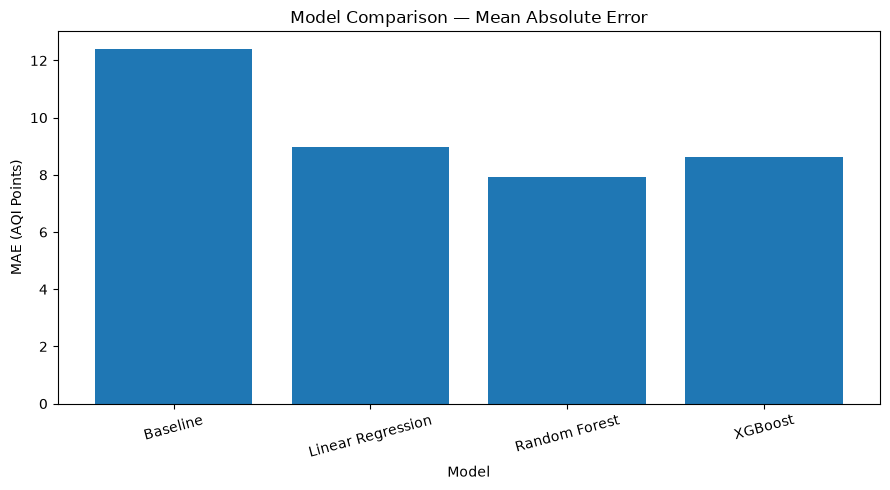

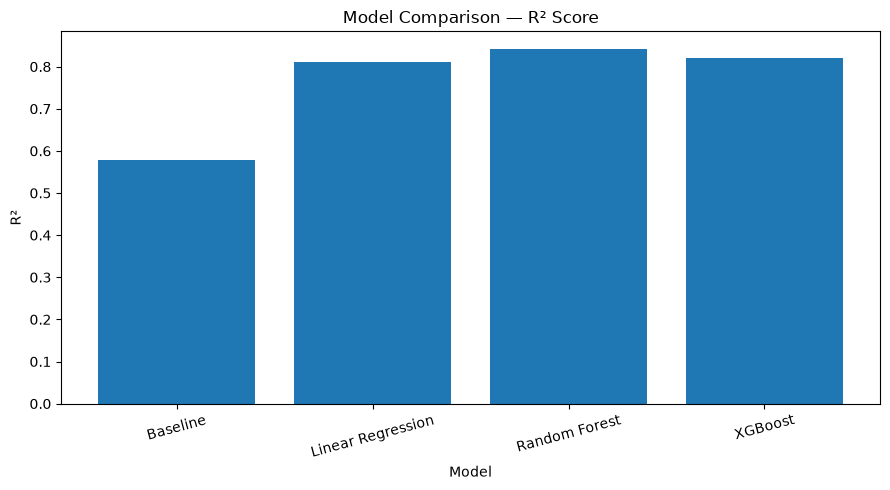

In [12]:
# ---------------------------------------------------------
# Compare all machine-learning models
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

print("FINAL MODEL COMPARISON")
display(results.round(3))

# MAE comparison
plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["MAE"])

plt.title("Model Comparison — Mean Absolute Error")
plt.ylabel("MAE (AQI Points)")
plt.xlabel("Model")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# R² comparison
plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison — R² Score")
plt.ylabel("R²")
plt.xlabel("Model")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

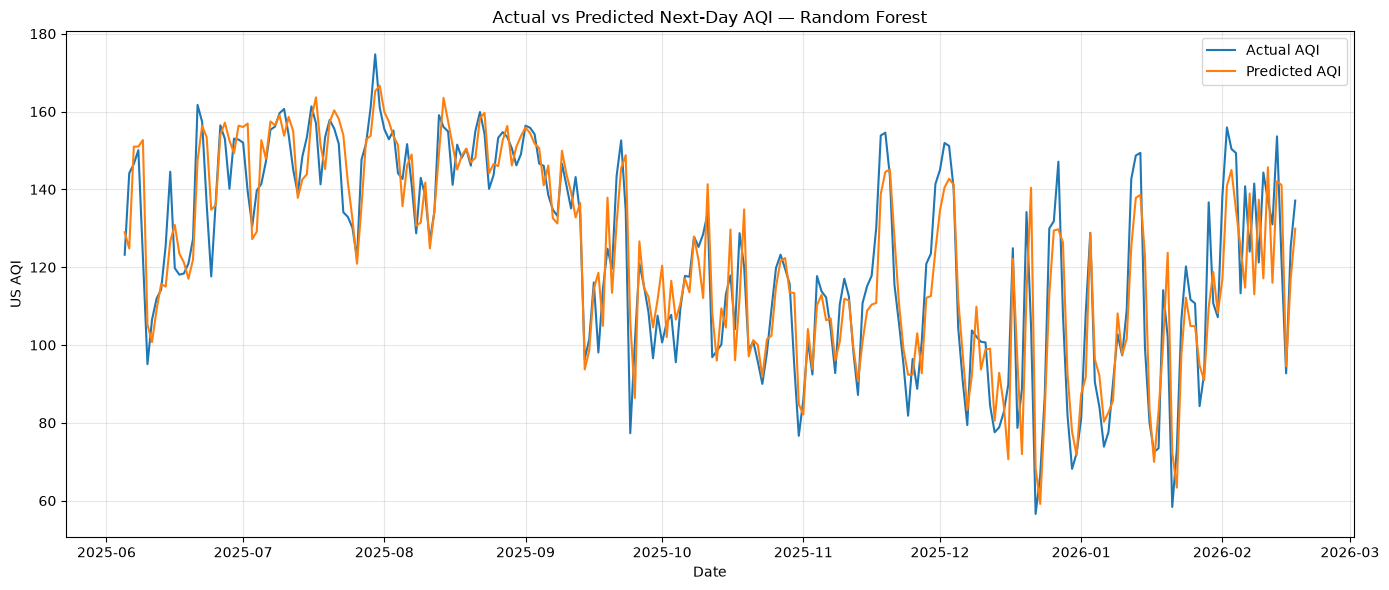

In [13]:
# ---------------------------------------------------------
# Actual vs Predicted AQI — Random Forest
# ---------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual AQI",
    linewidth=1.5
)

plt.plot(
    test_dates,
    rf_pred,
    label="Predicted AQI",
    linewidth=1.5
)

plt.title("Actual vs Predicted Next-Day AQI — Random Forest")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TOP 15 MOST IMPORTANT FEATURES
--------------------------------------------------


,Feature,Importance
1,pm2_5,0.7768
5,ozone,0.0477
9,us_aqi,0.0326
8,uv_index,0.0133
13,wind_speed,0.0109
11,temperature,0.0098
0,pm10,0.0095
6,aerosol_optical_depth,0.0079
26,temp_humidity,0.0076
3,nitrogen_dioxide,0.0064


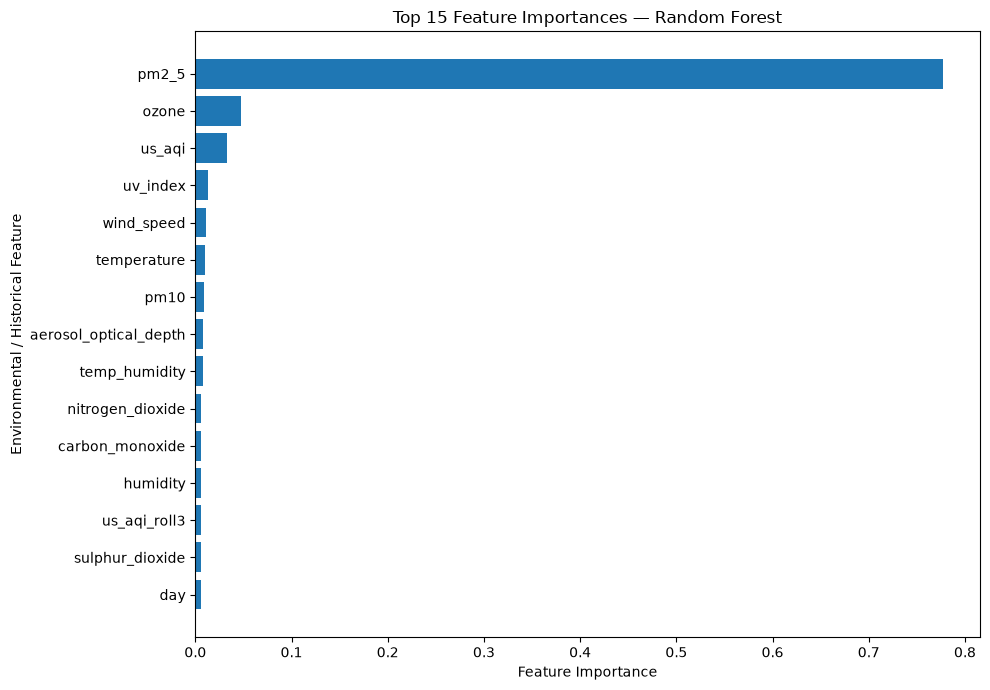

In [14]:
# ---------------------------------------------------------
# Random Forest Feature Importance
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from trained Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("TOP 15 MOST IMPORTANT FEATURES")
print("-" * 50)
display(feature_importance.head(15).round(4))

# Plot top 15
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Environmental / Historical Feature")

plt.tight_layout()
plt.show()

In [15]:
# ---------------------------------------------------------
# Advanced Feature Engineering
# Additional historical lag features
# ---------------------------------------------------------

# Make sure data is chronological
df = df.sort_values("date").reset_index(drop=True)

# Additional PM2.5 historical lags
df["pm2_5_lag2"] = df["pm2_5"].shift(2)
df["pm2_5_lag3"] = df["pm2_5"].shift(3)
df["pm2_5_lag7"] = df["pm2_5"].shift(7)

# Additional PM10 historical lags
df["pm10_lag2"] = df["pm10"].shift(2)
df["pm10_lag3"] = df["pm10"].shift(3)
df["pm10_lag7"] = df["pm10"].shift(7)

# Additional AQI historical lags
df["us_aqi_lag2"] = df["us_aqi"].shift(2)
df["us_aqi_lag3"] = df["us_aqi"].shift(3)
df["us_aqi_lag7"] = df["us_aqi"].shift(7)

print("Additional lag features created successfully!")

new_lag_features = [
    "pm2_5_lag2", "pm2_5_lag3", "pm2_5_lag7",
    "pm10_lag2", "pm10_lag3", "pm10_lag7",
    "us_aqi_lag2", "us_aqi_lag3", "us_aqi_lag7"
]

display(
    df[
        ["date", "pm2_5", "pm10", "us_aqi"] +
        new_lag_features
    ].head(10)
)

print("\nMissing values:")
print(df[new_lag_features].isnull().sum())

Additional lag features created successfully!


,date,pm2_5,pm10,us_aqi,pm2_5_lag2,pm2_5_lag3,pm2_5_lag7,pm10_lag2,pm10_lag3,pm10_lag7,us_aqi_lag2,us_aqi_lag3,us_aqi_lag7
0,2022-08-08,62.745833,103.125000,207.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-09,45.358333,76.595833,146.791667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-10,59.287500,114.862500,144.583333,62.745833,NaN,NaN,103.125000,NaN,NaN,207.166667,NaN,NaN
3,2022-08-11,75.741667,165.525000,157.083333,45.358333,62.745833,NaN,76.595833,103.125000,NaN,146.791667,207.166667,NaN
4,2022-08-12,116.433333,190.825000,167.625000,59.287500,45.358333,NaN,114.862500,76.595833,NaN,144.583333,146.791667,NaN
5,2022-08-13,81.566667,140.454167,180.500000,75.741667,59.287500,NaN,165.525000,114.862500,NaN,157.083333,144.583333,NaN
6,2022-08-14,58.629167,111.983333,158.333333,116.433333,75.741667,NaN,190.825000,165.525000,NaN,167.625000,157.083333,NaN
7,2022-08-15,36.875000,66.800000,132.000000,81.566667,116.433333,62.745833,140.454167,190.825000,103.125000,180.500000,167.625000,207.166667
8,2022-08-16,48.033333,83.829167,112.166667,58.629167,81.566667,45.358333,111.983333,140.454167,76.595833,158.333333,180.500000,146.791667
9,2022-08-17,55.233333,93.566667,147.416667,36.875000,58.629167,59.287500,66.800000,111.983333,114.862500,132.000000,158.333333,144.583333



Missing values:
pm2_5_lag2     2
pm2_5_lag3     3
pm2_5_lag7     7
pm10_lag2      2
pm10_lag3      3
pm10_lag7      7
us_aqi_lag2    2
us_aqi_lag3    3
us_aqi_lag7    7
dtype: int64


In [16]:
# ---------------------------------------------------------
# Advanced Feature Engineering
# 7-day historical rolling features
# ---------------------------------------------------------

# Use shift(1) so today's value is NOT included
# in the historical rolling window

df["pm2_5_roll7"] = (
    df["pm2_5"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

df["pm10_roll7"] = (
    df["pm10"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

df["us_aqi_roll7"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

print("7-day rolling features created successfully!")

rolling_features = [
    "pm2_5_roll7",
    "pm10_roll7",
    "us_aqi_roll7"
]

display(
    df[
        ["date", "pm2_5", "pm2_5_roll7",
         "pm10", "pm10_roll7",
         "us_aqi", "us_aqi_roll7"]
    ].head(12)
)

print("\nMissing values:")
print(df[rolling_features].isnull().sum())

7-day rolling features created successfully!


,date,pm2_5,pm2_5_roll7,pm10,pm10_roll7,us_aqi,us_aqi_roll7
0,2022-08-08,62.745833,NaN,103.125000,NaN,207.166667,NaN
1,2022-08-09,45.358333,NaN,76.595833,NaN,146.791667,NaN
2,2022-08-10,59.287500,NaN,114.862500,NaN,144.583333,NaN
3,2022-08-11,75.741667,NaN,165.525000,NaN,157.083333,NaN
4,2022-08-12,116.433333,NaN,190.825000,NaN,167.625000,NaN
5,2022-08-13,81.566667,NaN,140.454167,NaN,180.500000,NaN
6,2022-08-14,58.629167,NaN,111.983333,NaN,158.333333,NaN
7,2022-08-15,36.875000,71.394643,66.800000,129.052976,132.000000,166.011905
8,2022-08-16,48.033333,67.698810,83.829167,123.863690,112.166667,155.273810
9,2022-08-17,55.233333,68.080952,93.566667,124.897024,147.416667,150.327381



Missing values:
pm2_5_roll7     7
pm10_roll7      7
us_aqi_roll7    7
dtype: int64


In [17]:
# ---------------------------------------------------------
# Advanced Feature Engineering
# Pollution trend / change features
# ---------------------------------------------------------

# Change from yesterday to today
df["pm2_5_change1"] = df["pm2_5"] - df["pm2_5_lag1"]
df["pm10_change1"] = df["pm10"] - df["pm10_lag1"]
df["aqi_change1"] = df["us_aqi"] - df["us_aqi_lag1"]

# Difference between current value and recent 3-day trend
df["pm2_5_vs_roll3"] = df["pm2_5"] - df["pm2_5_roll3"]
df["pm10_vs_roll3"] = df["pm10"] - df["pm10_roll3"]
df["aqi_vs_roll3"] = df["us_aqi"] - df["us_aqi_roll3"]

trend_features = [
    "pm2_5_change1",
    "pm10_change1",
    "aqi_change1",
    "pm2_5_vs_roll3",
    "pm10_vs_roll3",
    "aqi_vs_roll3"
]

print("Pollution trend features created successfully!")

display(
    df[
        ["date", "pm2_5", "pm2_5_change1",
         "pm10", "pm10_change1",
         "us_aqi", "aqi_change1"]
    ].head(10)
)

print("\nMissing values:")
print(df[trend_features].isnull().sum())

Pollution trend features created successfully!


,date,pm2_5,pm2_5_change1,pm10,pm10_change1,us_aqi,aqi_change1
0,2022-08-08,62.745833,-31.012500,103.125000,-47.566667,207.166667,26.875000
1,2022-08-09,45.358333,-17.387500,76.595833,-26.529167,146.791667,-60.375000
2,2022-08-10,59.287500,13.929167,114.862500,38.266667,144.583333,-2.208333
3,2022-08-11,75.741667,16.454167,165.525000,50.662500,157.083333,12.500000
4,2022-08-12,116.433333,40.691667,190.825000,25.300000,167.625000,10.541667
5,2022-08-13,81.566667,-34.866667,140.454167,-50.370833,180.500000,12.875000
6,2022-08-14,58.629167,-22.937500,111.983333,-28.470833,158.333333,-22.166667
7,2022-08-15,36.875000,-21.754167,66.800000,-45.183333,132.000000,-26.333333
8,2022-08-16,48.033333,11.158333,83.829167,17.029167,112.166667,-19.833333
9,2022-08-17,55.233333,7.200000,93.566667,9.737500,147.416667,35.250000



Missing values:
pm2_5_change1     0
pm10_change1      0
aqi_change1       0
pm2_5_vs_roll3    0
pm10_vs_roll3     0
aqi_vs_roll3      0
dtype: int64


In [18]:
# ---------------------------------------------------------
# Build Advanced ML Dataset
# ---------------------------------------------------------

# Recreate next-day target
df["target_aqi_next_day"] = df["us_aqi"].shift(-1)

# Advanced features requiring historical data
advanced_required = [
    "pm2_5_lag2", "pm2_5_lag3", "pm2_5_lag7",
    "pm10_lag2", "pm10_lag3", "pm10_lag7",
    "us_aqi_lag2", "us_aqi_lag3", "us_aqi_lag7",
    "pm2_5_roll7", "pm10_roll7", "us_aqi_roll7",
    "target_aqi_next_day"
]

# Remove only rows without sufficient history / target
df_advanced = df.dropna(subset=advanced_required).copy()
df_advanced.reset_index(drop=True, inplace=True)

# Remove non-model columns
drop_columns_advanced = [
    "date",
    "season",
    "target_aqi_next_day"
]

X_advanced = df_advanced.drop(columns=drop_columns_advanced)
y_advanced = df_advanced["target_aqi_next_day"]

# Chronological 80/20 split
advanced_split = int(len(df_advanced) * 0.80)

X_train_adv = X_advanced.iloc[:advanced_split].copy()
X_test_adv = X_advanced.iloc[advanced_split:].copy()

y_train_adv = y_advanced.iloc[:advanced_split].copy()
y_test_adv = y_advanced.iloc[advanced_split:].copy()

train_dates_adv = df_advanced["date"].iloc[:advanced_split]
test_dates_adv = df_advanced["date"].iloc[advanced_split:]

print("ADVANCED DATASET READY")
print("-" * 45)

print("Total samples:", len(df_advanced))
print("Number of features:", X_advanced.shape[1])

print("\nTraining samples:", len(X_train_adv))
print("Testing samples:", len(X_test_adv))

print("\nTraining period:")
print(train_dates_adv.min(), "to", train_dates_adv.max())

print("\nTesting period:")
print(test_dates_adv.min(), "to", test_dates_adv.max())

print("\nMissing X values:", X_advanced.isnull().sum().sum())
print("Missing y values:", y_advanced.isnull().sum())

print("\nTarget included in X:",
      "target_aqi_next_day" in X_advanced.columns)

ADVANCED DATASET READY
---------------------------------------------
Total samples: 1283
Number of features: 46

Training samples: 1026
Testing samples: 257

Training period:
2022-08-15 00:00:00 to 2025-06-05 00:00:00

Testing period:
2025-06-06 00:00:00 to 2026-02-17 00:00:00

Missing X values: 0
Missing y values: 0

Target included in X: False


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training Advanced Random Forest...")

rf_advanced = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.8,
    random_state=42,
    n_jobs=-1
)

rf_advanced.fit(X_train_adv, y_train_adv)

# Predict
rf_adv_pred = rf_advanced.predict(X_test_adv)

# Evaluate
rf_adv_mae = mean_absolute_error(y_test_adv, rf_adv_pred)
rf_adv_rmse = np.sqrt(mean_squared_error(y_test_adv, rf_adv_pred))
rf_adv_r2 = r2_score(y_test_adv, rf_adv_pred)

print("\nADVANCED RANDOM FOREST RESULTS")
print("-" * 45)
print(f"MAE  : {rf_adv_mae:.3f}")
print(f"RMSE : {rf_adv_rmse:.3f}")
print(f"R²   : {rf_adv_r2:.3f}")

print("\nCOMPARISON WITH ORIGINAL RANDOM FOREST")
print("-" * 45)
print("Original RF R² : 0.842")
print(f"Advanced RF R² : {rf_adv_r2:.3f}")

print("\nOriginal RF MAE : 7.909")
print(f"Advanced RF MAE : {rf_adv_mae:.3f}")

print("\nOriginal RF RMSE : 10.215")
print(f"Advanced RF RMSE : {rf_adv_rmse:.3f}")

Training Advanced Random Forest...

ADVANCED RANDOM FOREST RESULTS
---------------------------------------------
MAE  : 8.123
RMSE : 10.386
R²   : 0.837

COMPARISON WITH ORIGINAL RANDOM FOREST
---------------------------------------------
Original RF R² : 0.842
Advanced RF R² : 0.837

Original RF MAE : 7.909
Advanced RF MAE : 8.123

Original RF RMSE : 10.215
Advanced RF RMSE : 10.386


In [20]:
# ---------------------------------------------------------
# Model Improvement: Extra Trees Regressor
# ---------------------------------------------------------

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Training Extra Trees model...")

extra_model = ExtraTreesRegressor(
    n_estimators=500,
    max_features=0.8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train, y_train)

extra_pred = extra_model.predict(X_test)

extra_mae = mean_absolute_error(y_test, extra_pred)
extra_rmse = np.sqrt(mean_squared_error(y_test, extra_pred))
extra_r2 = r2_score(y_test, extra_pred)

print("\nEXTRA TREES RESULTS")
print("-" * 45)

print(f"MAE  : {extra_mae:.3f}")
print(f"RMSE : {extra_rmse:.3f}")
print(f"R²   : {extra_r2:.3f}")

print("\nCOMPARISON")
print("-" * 45)

print(f"Random Forest R² : {rf_r2:.3f}")
print(f"Extra Trees R²   : {extra_r2:.3f}")

print(f"\nRandom Forest MAE : {rf_mae:.3f}")
print(f"Extra Trees MAE   : {extra_mae:.3f}")

print(f"\nRandom Forest RMSE : {rf_rmse:.3f}")
print(f"Extra Trees RMSE   : {extra_rmse:.3f}")

Training Extra Trees model...

EXTRA TREES RESULTS
---------------------------------------------
MAE  : 8.543
RMSE : 10.932
R²   : 0.819

COMPARISON
---------------------------------------------
Random Forest R² : 0.842
Extra Trees R²   : 0.819

Random Forest MAE : 7.909
Extra Trees MAE   : 8.543

Random Forest RMSE : 10.215
Extra Trees RMSE   : 10.932


In [21]:
# ---------------------------------------------------------
# Time-Series Cross-Validation Setup
# ---------------------------------------------------------

from sklearn.model_selection import TimeSeriesSplit

# 5 chronological validation folds
tscv = TimeSeriesSplit(n_splits=5)

print("TIME-SERIES CROSS-VALIDATION")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    print(f"\nFold {fold}")

    print(
        "Training samples:",
        len(train_idx),
        "| Validation samples:",
        len(val_idx)
    )

    print(
        "Training index:",
        train_idx[0],
        "to",
        train_idx[-1]
    )

    print(
        "Validation index:",
        val_idx[0],
        "to",
        val_idx[-1]
    )

print("\nTime-series cross-validation setup completed!")

TIME-SERIES CROSS-VALIDATION
---------------------------------------------

Fold 1
Training samples: 172 | Validation samples: 172
Training index: 0 to 171
Validation index: 172 to 343

Fold 2
Training samples: 344 | Validation samples: 172
Training index: 0 to 343
Validation index: 344 to 515

Fold 3
Training samples: 516 | Validation samples: 172
Training index: 0 to 515
Validation index: 516 to 687

Fold 4
Training samples: 688 | Validation samples: 172
Training index: 0 to 687
Validation index: 688 to 859

Fold 5
Training samples: 860 | Validation samples: 172
Training index: 0 to 859
Validation index: 860 to 1031

Time-series cross-validation setup completed!


In [22]:
# ---------------------------------------------------------
# Random Forest Hyperparameter Tuning
# Using Time-Series Cross-Validation
# ---------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("Starting Random Forest tuning...")

# Base model
rf_tuning_model = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

# Parameters to explore
param_distributions = {
    "n_estimators": [200, 300, 500, 700, 900],
    "max_depth": [None, 8, 12, 16, 20, 25],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [0.5, 0.7, 0.8, 1.0, "sqrt"]
}

# Randomized search using ONLY training data
rf_search = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="r2",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\nTUNING COMPLETED")
print("-" * 45)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest Time-Series CV R²:")
print(round(rf_search.best_score_, 4))

Starting Random Forest tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

TUNING COMPLETED
---------------------------------------------
Best parameters:
{'n_estimators': 900, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': 12}

Best Time-Series CV R²:
0.751


In [23]:
# ---------------------------------------------------------
# Evaluate Tuned Random Forest on Holdout Test Data
# ---------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Evaluating tuned Random Forest...")

# Best model automatically selected by RandomizedSearchCV
tuned_rf = rf_search.best_estimator_

# Predict the untouched future test period
tuned_rf_pred = tuned_rf.predict(X_test)

# Evaluation metrics
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_pred)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_pred))
tuned_rf_r2 = r2_score(y_test, tuned_rf_pred)

print("\nTUNED RANDOM FOREST RESULTS")
print("-" * 45)

print(f"MAE  : {tuned_rf_mae:.3f}")
print(f"RMSE : {tuned_rf_rmse:.3f}")
print(f"R²   : {tuned_rf_r2:.3f}")

print("\nCOMPARISON WITH ORIGINAL RANDOM FOREST")
print("-" * 45)

print(f"Original RF MAE  : {rf_mae:.3f}")
print(f"Tuned RF MAE     : {tuned_rf_mae:.3f}")

print()

print(f"Original RF RMSE : {rf_rmse:.3f}")
print(f"Tuned RF RMSE    : {tuned_rf_rmse:.3f}")

print()

print(f"Original RF R²   : {rf_r2:.3f}")
print(f"Tuned RF R²      : {tuned_rf_r2:.3f}")

if tuned_rf_r2 > rf_r2:
    print("\n✅ Tuned Random Forest improved the original model.")
else:
    print("\n⚠️ Tuning did not improve the original Random Forest.")

Evaluating tuned Random Forest...

TUNED RANDOM FOREST RESULTS
---------------------------------------------
MAE  : 8.116
RMSE : 10.399
R²   : 0.836

COMPARISON WITH ORIGINAL RANDOM FOREST
---------------------------------------------
Original RF MAE  : 7.909
Tuned RF MAE     : 8.116

Original RF RMSE : 10.215
Tuned RF RMSE    : 10.399

Original RF R²   : 0.842
Tuned RF R²      : 0.836

⚠️ Tuning did not improve the original Random Forest.


In [24]:
# ---------------------------------------------------------
# XGBoost Hyperparameter Tuning
# Using Time-Series Cross-Validation
# ---------------------------------------------------------

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

print("Starting XGBoost time-series tuning...")

xgb_tuning_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)

xgb_param_distributions = {
    "n_estimators": [200, 300, 500, 700, 900],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1, 2, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=xgb_param_distributions,
    n_iter=35,
    scoring="r2",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("\nXGBOOST TUNING COMPLETED")
print("-" * 50)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest Time-Series CV R²:")
print(round(xgb_search.best_score_, 4))

Starting XGBoost time-series tuning...
Fitting 5 folds for each of 35 candidates, totalling 175 fits

XGBOOST TUNING COMPLETED
--------------------------------------------------
Best parameters:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

Best Time-Series CV R²:
0.7541


In [25]:
# ---------------------------------------------------------
# Evaluate Tuned XGBoost on Holdout Test Data
# ---------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Evaluating tuned XGBoost...")

# Best XGBoost model found during time-series tuning
tuned_xgb = xgb_search.best_estimator_

# Predict on the future holdout test set
tuned_xgb_pred = tuned_xgb.predict(X_test)

# Metrics
tuned_xgb_mae = mean_absolute_error(y_test, tuned_xgb_pred)
tuned_xgb_rmse = np.sqrt(mean_squared_error(y_test, tuned_xgb_pred))
tuned_xgb_r2 = r2_score(y_test, tuned_xgb_pred)

print("\nTUNED XGBOOST RESULTS")
print("-" * 45)

print(f"MAE  : {tuned_xgb_mae:.3f}")
print(f"RMSE : {tuned_xgb_rmse:.3f}")
print(f"R²   : {tuned_xgb_r2:.3f}")

print("\nCURRENT BEST MODEL COMPARISON")
print("-" * 45)

print(f"Original Random Forest R² : {rf_r2:.3f}")
print(f"Tuned XGBoost R²          : {tuned_xgb_r2:.3f}")

print()

print(f"Original Random Forest MAE : {rf_mae:.3f}")
print(f"Tuned XGBoost MAE          : {tuned_xgb_mae:.3f}")

print()

print(f"Original Random Forest RMSE : {rf_rmse:.3f}")
print(f"Tuned XGBoost RMSE          : {tuned_xgb_rmse:.3f}")

if tuned_xgb_r2 > rf_r2:
    print("\n✅ Tuned XGBoost is now the best model.")
else:
    print("\n⚠️ Original Random Forest remains the best model.")

Evaluating tuned XGBoost...

TUNED XGBOOST RESULTS
---------------------------------------------
MAE  : 8.374
RMSE : 10.663
R²   : 0.828

CURRENT BEST MODEL COMPARISON
---------------------------------------------
Original Random Forest R² : 0.842
Tuned XGBoost R²          : 0.828

Original Random Forest MAE : 7.909
Tuned XGBoost MAE          : 8.374

Original Random Forest RMSE : 10.215
Tuned XGBoost RMSE          : 10.663

⚠️ Original Random Forest remains the best model.


In [26]:
# ---------------------------------------------------------
# Time-Series Stacking Ensemble
# Random Forest + XGBoost + Linear Regression
# ---------------------------------------------------------

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Building time-series ensemble...")

# Storage for out-of-fold predictions
oof_rf = np.full(len(X_train), np.nan)
oof_xgb = np.full(len(X_train), np.nan)
oof_linear = np.full(len(X_train), np.nan)

# ---------------------------------------------------------
# Generate chronological validation predictions
# ---------------------------------------------------------

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_val = X_train.iloc[val_idx]

    # Random Forest
    rf_fold = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    # Best tuned XGBoost
    xgb_fold = XGBRegressor(
        **xgb_search.best_params_,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    # Linear Regression
    linear_fold = LinearRegression()

    rf_fold.fit(X_fold_train, y_fold_train)
    xgb_fold.fit(X_fold_train, y_fold_train)
    linear_fold.fit(X_fold_train, y_fold_train)

    oof_rf[val_idx] = rf_fold.predict(X_fold_val)
    oof_xgb[val_idx] = xgb_fold.predict(X_fold_val)
    oof_linear[val_idx] = linear_fold.predict(X_fold_val)

    print(f"Fold {fold} completed")

# ---------------------------------------------------------
# Keep only samples that have validation predictions
# ---------------------------------------------------------

valid_mask = ~np.isnan(oof_rf)

stack_train = np.column_stack([
    oof_rf[valid_mask],
    oof_xgb[valid_mask],
    oof_linear[valid_mask]
])

stack_target = y_train.iloc[np.where(valid_mask)[0]]

# ---------------------------------------------------------
# Meta-model learns how to combine the three predictions
# ---------------------------------------------------------

meta_model = LinearRegression()

meta_model.fit(stack_train, stack_target)

print("\nENSEMBLE WEIGHTS")
print("-" * 45)

print(f"Random Forest weight : {meta_model.coef_[0]:.3f}")
print(f"XGBoost weight       : {meta_model.coef_[1]:.3f}")
print(f"Linear weight        : {meta_model.coef_[2]:.3f}")
print(f"Intercept            : {meta_model.intercept_:.3f}")

# ---------------------------------------------------------
# Train base models on complete training dataset
# ---------------------------------------------------------

final_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_xgb = XGBRegressor(
    **xgb_search.best_params_,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_linear = LinearRegression()

final_rf.fit(X_train, y_train)
final_xgb.fit(X_train, y_train)
final_linear.fit(X_train, y_train)

# ---------------------------------------------------------
# Predict holdout future data
# ---------------------------------------------------------

rf_test_pred = final_rf.predict(X_test)
xgb_test_pred = final_xgb.predict(X_test)
linear_test_pred = final_linear.predict(X_test)

stack_test = np.column_stack([
    rf_test_pred,
    xgb_test_pred,
    linear_test_pred
])

ensemble_pred = meta_model.predict(stack_test)

# ---------------------------------------------------------
# Evaluate
# ---------------------------------------------------------

ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)

print("\nSTACKING ENSEMBLE RESULTS")
print("-" * 45)

print(f"MAE  : {ensemble_mae:.3f}")
print(f"RMSE : {ensemble_rmse:.3f}")
print(f"R²   : {ensemble_r2:.3f}")

print("\nCURRENT CHAMPION COMPARISON")
print("-" * 45)

print(f"Random Forest R² : {rf_r2:.3f}")
print(f"Ensemble R²      : {ensemble_r2:.3f}")

if ensemble_r2 > rf_r2:
    print("\n✅ Ensemble improved prediction performance.")
else:
    print("\n⚠️ Random Forest remains the stronger holdout model.")

Building time-series ensemble...
Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

ENSEMBLE WEIGHTS
---------------------------------------------
Random Forest weight : 0.213
XGBoost weight       : 0.765
Linear weight        : 0.012
Intercept            : 2.820

STACKING ENSEMBLE RESULTS
---------------------------------------------
MAE  : 8.201
RMSE : 10.408
R²   : 0.836

CURRENT CHAMPION COMPARISON
---------------------------------------------
Random Forest R² : 0.842
Ensemble R²      : 0.836

⚠️ Random Forest remains the stronger holdout model.


In [27]:
# ---------------------------------------------------------
# Error Analysis - Best Random Forest Model
# ---------------------------------------------------------

import pandas as pd
import numpy as np

print("Running error analysis for the best Random Forest...")

# Create dataframe containing actual and predicted values
error_df = pd.DataFrame({
    "actual_aqi": y_test.values,
    "predicted_aqi": rf_pred
})

# Calculate errors
error_df["error"] = error_df["actual_aqi"] - error_df["predicted_aqi"]
error_df["absolute_error"] = np.abs(error_df["error"])

# Add the corresponding dates
error_df["date"] = df.iloc[X_test.index]["date"].values

# ---------------------------------------------------------
# AQI severity groups
# ---------------------------------------------------------

error_df["aqi_group"] = pd.cut(
    error_df["actual_aqi"],
    bins=[0, 50, 100, 150, 200, 300, np.inf],
    labels=[
        "0-50",
        "51-100",
        "101-150",
        "151-200",
        "201-300",
        "300+"
    ]
)

print("\nOVERALL ERROR SUMMARY")
print("-" * 50)

print(f"Mean Absolute Error : {error_df['absolute_error'].mean():.3f}")
print(f"Median Error        : {error_df['absolute_error'].median():.3f}")
print(f"Maximum Error       : {error_df['absolute_error'].max():.3f}")

print("\nERROR BY AQI LEVEL")
print("-" * 50)

group_error = (
    error_df
    .groupby("aqi_group", observed=True)
    .agg(
        samples=("actual_aqi", "count"),
        mean_actual_aqi=("actual_aqi", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        max_absolute_error=("absolute_error", "max")
    )
)

print(group_error.round(2))

print("\n10 LARGEST PREDICTION ERRORS")
print("-" * 50)

largest_errors = (
    error_df
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

print(
    largest_errors[
        [
            "date",
            "actual_aqi",
            "predicted_aqi",
            "absolute_error",
            "aqi_group"
        ]
    ].round(2)
)

Running error analysis for the best Random Forest...

OVERALL ERROR SUMMARY
--------------------------------------------------
Mean Absolute Error : 7.909
Median Error        : 6.418
Maximum Error       : 35.661

ERROR BY AQI LEVEL
--------------------------------------------------
           samples  mean_actual_aqi  mean_absolute_error  max_absolute_error
aqi_group                                                                   
51-100          54            85.76                 8.01               28.68
101-150        153           125.52                 8.73               35.66
151-200         51           155.28                 5.34               15.02

10 LARGEST PREDICTION ERRORS
--------------------------------------------------
          date  actual_aqi  predicted_aqi  absolute_error aqi_group
199 2025-12-21      104.75         140.41           35.66   101-150
4   2025-06-09      122.67         152.68           30.02   101-150
111 2025-09-24       77.33         106.01      

/var/folders/_f/cx2gdsw92ks6118dnf6ttxyr0000gn/T/ipykernel_1189/3202928241.py:81: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


In [28]:
# ---------------------------------------------------------
# Health-Risk Category & Alert Evaluation
# Best Random Forest Predictions
# ---------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Evaluating ClimaCare health-risk warning performance...")

# ---------------------------------------------------------
# Function to convert AQI number into health-risk category
# ---------------------------------------------------------

def aqi_category(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"

    elif aqi <= 200:
        return "Unhealthy"

    elif aqi <= 300:
        return "Very Unhealthy"

    else:
        return "Hazardous"


# Actual and predicted AQI categories
actual_categories = pd.Series(y_test.values).apply(aqi_category)

predicted_categories = pd.Series(rf_pred).apply(aqi_category)


# ---------------------------------------------------------
# Multi-class category accuracy
# ---------------------------------------------------------

category_accuracy = accuracy_score(
    actual_categories,
    predicted_categories
)

print("\nAQI HEALTH-RISK CATEGORY PERFORMANCE")
print("-" * 55)

print(
    f"Category Accuracy : "
    f"{category_accuracy * 100:.2f}%"
)


print("\nCLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        actual_categories,
        predicted_categories,
        zero_division=0
    )
)


# ---------------------------------------------------------
# Binary public-health alert test
#
# AQI > 100 = warning needed
# ---------------------------------------------------------

actual_alert = (y_test.values > 100).astype(int)
predicted_alert = (rf_pred > 100).astype(int)

alert_accuracy = accuracy_score(
    actual_alert,
    predicted_alert
)

alert_precision = precision_score(
    actual_alert,
    predicted_alert,
    zero_division=0
)

alert_recall = recall_score(
    actual_alert,
    predicted_alert,
    zero_division=0
)

alert_f1 = f1_score(
    actual_alert,
    predicted_alert,
    zero_division=0
)

print("\nCLIMACARE HEALTH ALERT PERFORMANCE")
print("-" * 55)

print(f"Alert Accuracy  : {alert_accuracy * 100:.2f}%")
print(f"Alert Precision : {alert_precision * 100:.2f}%")
print(f"Alert Recall    : {alert_recall * 100:.2f}%")
print(f"Alert F1 Score  : {alert_f1 * 100:.2f}%")


# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    actual_alert,
    predicted_alert
).ravel()

print("\nALERT CONFUSION MATRIX")
print("-" * 55)

print("Correct safe predictions        :", tn)
print("False warnings                  :", fp)
print("Missed risky days               :", fn)
print("Correct risky-day warnings      :", tp)

print("\nMost important value for safety:")
print("Missed risky days =", fn)

Evaluating ClimaCare health-risk warning performance...

AQI HEALTH-RISK CATEGORY PERFORMANCE
-------------------------------------------------------
Category Accuracy : 79.84%

CLASSIFICATION REPORT
-------------------------------------------------------
                                precision    recall  f1-score   support

                      Moderate       0.83      0.80      0.81        54
                     Unhealthy       0.70      0.65      0.67        51
Unhealthy for Sensitive Groups       0.82      0.85      0.83       153

                      accuracy                           0.80       258
                     macro avg       0.78      0.76      0.77       258
                  weighted avg       0.80      0.80      0.80       258


CLIMACARE HEALTH ALERT PERFORMANCE
-------------------------------------------------------
Alert Accuracy  : 92.25%
Alert Precision : 94.66%
Alert Recall    : 95.59%
Alert F1 Score  : 95.12%

ALERT CONFUSION MATRIX
---------------------

In [31]:
# ---------------------------------------------------------
# Health-Risk Category & Alert Evaluation
# Best Random Forest Predictions
# ---------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Evaluating ClimaCare health-risk warning performance...")

# ---------------------------------------------------------
# Function to convert AQI number into health-risk category
# ---------------------------------------------------------

def aqi_category(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"

    elif aqi <= 200:
        return "Unhealthy"

    elif aqi <= 300:
        return "Very Unhealthy"

    else:
        return "Hazardous"


# Actual and predicted AQI categories
actual_categories = pd.Series(y_test.values).apply(aqi_category)

predicted_categories = pd.Series(rf_pred).apply(aqi_category)


# ---------------------------------------------------------
# Multi-class category accuracy
# ---------------------------------------------------------

category_accuracy = accuracy_score(
    actual_categories,
    predicted_categories
)

print("\nAQI HEALTH-RISK CATEGORY PERFORMANCE")
print("-" * 55)

print(
    f"Category Accuracy : "
    f"{category_accuracy * 100:.2f}%"
)


print("\nCLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        actual_categories,
        predicted_categories,
        zero_division=0
    )
)


# ---------------------------------------------------------
# Binary public-health alert test
#
# AQI > 100 = warning needed
# ---------------------------------------------------------

actual_alert = (y_test.values > 100).astype(int)
predicted_alert = (rf_pred > 100).astype(int)

alert_accuracy = accuracy_score(
    actual_alert,
    predicted_alert
)

alert_precision = precision_score(
    actual_alert,
    predicted_alert,
    zero_division=0
)

alert_recall = recall_score(
    actual_alert,
    predicted_alert,
    zero_division=0
)

alert_f1 = f1_score(
    actual_alert,
    predicted_alert,
    zero_division=0
)

print("\nCLIMACARE HEALTH ALERT PERFORMANCE")
print("-" * 55)

print(f"Alert Accuracy  : {alert_accuracy * 100:.2f}%")
print(f"Alert Precision : {alert_precision * 100:.2f}%")
print(f"Alert Recall    : {alert_recall * 100:.2f}%")
print(f"Alert F1 Score  : {alert_f1 * 100:.2f}%")


# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    actual_alert,
    predicted_alert
).ravel()

print("\nALERT CONFUSION MATRIX")
print("-" * 55)

print("Correct safe predictions        :", tn)
print("False warnings                  :", fp)
print("Missed risky days               :", fn)
print("Correct risky-day warnings      :", tp)

print("\nMost important value for safety:")
print("Missed risky days =", fn)

Evaluating ClimaCare health-risk warning performance...

AQI HEALTH-RISK CATEGORY PERFORMANCE
-------------------------------------------------------
Category Accuracy : 79.84%

CLASSIFICATION REPORT
-------------------------------------------------------
                                precision    recall  f1-score   support

                      Moderate       0.83      0.80      0.81        54
                     Unhealthy       0.70      0.65      0.67        51
Unhealthy for Sensitive Groups       0.82      0.85      0.83       153

                      accuracy                           0.80       258
                     macro avg       0.78      0.76      0.77       258
                  weighted avg       0.80      0.80      0.80       258


CLIMACARE HEALTH ALERT PERFORMANCE
-------------------------------------------------------
Alert Accuracy  : 92.25%
Alert Precision : 94.66%
Alert Recall    : 95.59%
Alert F1 Score  : 95.12%

ALERT CONFUSION MATRIX
---------------------

In [32]:
# ---------------------------------------------------------
# ClimaCare Alert Threshold Optimization
# Using TRAINING Time-Series Predictions Only
# ---------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

print("Optimizing ClimaCare health-alert threshold...")

# ---------------------------------------------------------
# Use ONLY chronological out-of-fold TRAINING predictions
# ---------------------------------------------------------

valid_mask = ~np.isnan(oof_rf)

cv_actual_aqi = y_train.iloc[
    np.where(valid_mask)[0]
].values

cv_predicted_aqi = oof_rf[valid_mask]

# True health-risk definition remains AQI > 100
cv_actual_alert = (cv_actual_aqi > 100).astype(int)

# ---------------------------------------------------------
# Try different prediction-warning thresholds
# ---------------------------------------------------------

threshold_results = []

for threshold in range(85, 111):

    cv_pred_alert = (
        cv_predicted_aqi > threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            cv_actual_alert,
            cv_pred_alert
        ),

        "precision": precision_score(
            cv_actual_alert,
            cv_pred_alert,
            zero_division=0
        ),

        "recall": recall_score(
            cv_actual_alert,
            cv_pred_alert,
            zero_division=0
        ),

        "f1": f1_score(
            cv_actual_alert,
            cv_pred_alert,
            zero_division=0
        ),

        # F2 gives more importance to recall
        "f2": fbeta_score(
            cv_actual_alert,
            cv_pred_alert,
            beta=2,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

# ---------------------------------------------------------
# Select threshold with best F2 score
# ---------------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["f2"].idxmax()
]

best_alert_threshold = int(
    best_row["threshold"]
)

print("\nBEST TRAINING-DERIVED ALERT THRESHOLD")
print("-" * 55)

print("Threshold :", best_alert_threshold)

print(
    f"CV Precision : "
    f"{best_row['precision'] * 100:.2f}%"
)

print(
    f"CV Recall    : "
    f"{best_row['recall'] * 100:.2f}%"
)

print(
    f"CV F1        : "
    f"{best_row['f1'] * 100:.2f}%"
)

print(
    f"CV F2        : "
    f"{best_row['f2'] * 100:.2f}%"
)

print("\nTop candidate thresholds:")

print(
    threshold_df
    .sort_values("f2", ascending=False)
    .head(10)
    .round(4)
)


# ---------------------------------------------------------
# FINAL evaluation on holdout test data
# ---------------------------------------------------------

actual_alert_test = (
    y_test.values > 100
).astype(int)

optimized_alert_test = (
    rf_pred > best_alert_threshold
).astype(int)

opt_accuracy = accuracy_score(
    actual_alert_test,
    optimized_alert_test
)

opt_precision = precision_score(
    actual_alert_test,
    optimized_alert_test,
    zero_division=0
)

opt_recall = recall_score(
    actual_alert_test,
    optimized_alert_test,
    zero_division=0
)

opt_f1 = f1_score(
    actual_alert_test,
    optimized_alert_test,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    actual_alert_test,
    optimized_alert_test,
    labels=[0, 1]
).ravel()

print("\nOPTIMIZED HOLDOUT ALERT PERFORMANCE")
print("-" * 55)

print(
    f"Alert Threshold : {best_alert_threshold}"
)

print(
    f"Accuracy  : {opt_accuracy * 100:.2f}%"
)

print(
    f"Precision : {opt_precision * 100:.2f}%"
)

print(
    f"Recall    : {opt_recall * 100:.2f}%"
)

print(
    f"F1 Score  : {opt_f1 * 100:.2f}%"
)

print("\nConfusion Matrix")

print("Correct safe predictions   :", tn)
print("False warnings             :", fp)
print("Missed risky days          :", fn)
print("Correct risky-day warnings :", tp)

print("\nPrevious missed risky days = 9")
print("Optimized missed risky days =", fn)

Optimizing ClimaCare health-alert threshold...

BEST TRAINING-DERIVED ALERT THRESHOLD
-------------------------------------------------------
Threshold : 90
CV Precision : 78.19%
CV Recall    : 97.23%
CV F1        : 86.68%
CV F2        : 92.72%

Top candidate thresholds:
    threshold  accuracy  precision  recall      f1      f2
5          90    0.8116     0.7819  0.9723  0.8668  0.9272
6          91    0.8174     0.7895  0.9686  0.8699  0.9266
4          89    0.7977     0.7667  0.9760  0.8588  0.9255
7          92    0.8233     0.7982  0.9631  0.8729  0.9249
3          88    0.7907     0.7593  0.9779  0.8548  0.9246
8          93    0.8267     0.8037  0.9594  0.8747  0.9236
0          85    0.7686     0.7366  0.9852  0.8429  0.9229
2          87    0.7802     0.7489  0.9797  0.8489  0.9228
1          86    0.7721     0.7403  0.9834  0.8447  0.9228
12         97    0.8547     0.8435  0.9446  0.8912  0.9225

OPTIMIZED HOLDOUT ALERT PERFORMANCE
------------------------------------------

In [33]:
# ---------------------------------------------------------
# Compact Final Alert Performance Summary
# ---------------------------------------------------------

print("CLIMACARE OPTIMIZED EARLY-WARNING RESULTS")
print("-" * 50)

print(f"Selected threshold : {best_alert_threshold}")
print(f"Accuracy           : {opt_accuracy * 100:.2f}%")
print(f"Precision          : {opt_precision * 100:.2f}%")
print(f"Recall             : {opt_recall * 100:.2f}%")
print(f"F1 Score           : {opt_f1 * 100:.2f}%")

print("\nSafety outcomes")
print("-" * 50)

print(f"Correct safe days      : {tn}")
print(f"False warnings         : {fp}")
print(f"Missed risky days      : {fn}")
print(f"Correct risky warnings : {tp}")

print(
    f"\nRisky-day detection rate: "
    f"{tp / (tp + fn) * 100:.2f}%"
)

CLIMACARE OPTIMIZED EARLY-WARNING RESULTS
--------------------------------------------------
Selected threshold : 90
Accuracy           : 86.82%
Precision          : 86.02%
Recall             : 99.51%
F1 Score           : 92.27%

Safety outcomes
--------------------------------------------------
Correct safe days      : 21
False warnings         : 33
Missed risky days      : 1
Correct risky warnings : 203

Risky-day detection rate: 99.51%
